In [1]:
# Install PyTorch Geometric dependencies
import torch
import os

CUDA = 'cu' + torch.version.cuda.replace('.', '') if torch.cuda.is_available() else 'cpu'
TORCH = torch.__version__.split('+')[0]

# Install pyg_lib separately and handle failure gracefully
try:
    import subprocess
    subprocess.run([
        "pip", "install", "pyg_lib", "torch_scatter", "torch_sparse",
        "torch_cluster", "torch_spline_conv",
        "-f", f"https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html",
        "--quiet"
    ], check=True)
    print("PyG sparse libs installed.")
except Exception as e:
    print(f"Optional sparse libs failed (non-fatal): {e}")

import subprocess
subprocess.run(["pip", "install", "torch-geometric", "xgboost", "--quiet"], check=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

print("All imports ready.")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Optional sparse libs failed (non-fatal): Command '['pip', 'install', 'pyg_lib', 'torch_scatter', 'torch_sparse', 'torch_cluster', 'torch_spline_conv', '-f', 'https://data.pyg.org/whl/torch-2.10.0+cu128.html', '--quiet']' returned non-zero exit status 1.
All imports ready.
Device: cuda


In [2]:
from google.colab import drive
import zipfile

drive.mount('/content/drive')

zip_file_path = '/content/drive/MyDrive/PS_20174392719_1491204439457_log.csv.zip'
extraction_path = '/content/extracted_data'
os.makedirs(extraction_path, exist_ok=True)

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        print(f"Extracting {zip_file_path}...")
        zip_ref.extractall(extraction_path)
        print("Unzipping complete!")
except Exception as e:
    print(f"Error during unzip: {e}")

csv_path = '/content/extracted_data/PS_20174392719_1491204439457_log.csv'
print("Loading dataset...")
df = pd.read_csv(csv_path)
print(f"Dataset loaded: {len(df):,} rows")
print(df['isFraud'].value_counts())

Mounted at /content/drive
Extracting /content/drive/MyDrive/PS_20174392719_1491204439457_log.csv.zip...
Unzipping complete!
Loading dataset...
Dataset loaded: 6,362,620 rows
isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [4]:
def phase_1_preprocess(df, fraud_ratio=20, random_state=42):
    """
    Step-based stratified undersampling + neighbor enrichment.
    FIX: include_groups=False to suppress pandas deprecation warning.
    """
    df_fraud = df[df['isFraud'] == 1].copy()
    print(f"Total Fraud Transactions: {len(df_fraud):,}")

    def sample_normal(group):
        # 'step' column is already excluded from 'group' due to group_keys=False in groupby
        # So, no need to drop 'step' again.
        group_no_key = group
        n_fraud = group_no_key['isFraud'].sum()
        n_sample = int(max(n_fraud * fraud_ratio, 50))
        normal_idx = group_no_key[group_no_key['isFraud'] == 0].index
        if len(normal_idx) <= n_sample:
            return group_no_key[group_no_key['isFraud'] == 0]
        return group_no_key.loc[
            np.random.default_rng(random_state).choice(normal_idx, n_sample, replace=False)
        ]

    print("Sampling normal transactions step-by-step...")
    df_normal_sampled = df.groupby('step', group_keys=False).apply(
        sample_normal, include_groups=False
    )

    # Neighbor enrichment
    sampled_users = pd.concat([
        df_fraud['nameOrig'], df_fraud['nameDest'],
        df_normal_sampled['nameOrig'], df_normal_sampled['nameDest']
    ]).unique()

    df_neighbors = df[df['nameOrig'].isin(sampled_users) | df['nameDest'].isin(sampled_users)]
    df_neighbors = df_neighbors.groupby('nameOrig').tail(2)

    df_final = pd.concat([df_fraud, df_normal_sampled, df_neighbors]).drop_duplicates()
    df_final = df_final.sort_values(by='step').reset_index(drop=True)

    print(f"Sampled dataset size: {len(df_final):,} rows")
    print(f"Fraud rows: {df_final['isFraud'].sum():,}")
    return df_final


def inject_synthetic_features_clean(df, random_state=42):
    """
    FIX: IPs and device IDs are assigned purely randomly — NO label dependency.
    This removes data leakage from the original implementation.
    """
    rng = np.random.default_rng(random_state)
    n = len(df)

    # Purely random IPs and device IDs
    ip_pool = [f"10.{rng.integers(0,255)}.{rng.integers(0,255)}.{rng.integers(0,255)}" for _ in range(2000)]
    dev_pool = [f"DEVICE_{rng.integers(0, 999999):06d}" for _ in range(2000)]

    df = df.copy()
    df['ip_address'] = rng.choice(ip_pool, size=n)
    df['device_id']  = rng.choice(dev_pool, size=n)

    return df


# Run preprocessing
sampled_df = phase_1_preprocess(df)
sampled_df = inject_synthetic_features_clean(sampled_df)

print("\nClass distribution after sampling:")
print(sampled_df['isFraud'].value_counts())

Total Fraud Transactions: 8,213
Sampling normal transactions step-by-step...
Sampled dataset size: 874,350 rows
Fraud rows: 8,213

Class distribution after sampling:
isFraud
0    866137
1      8213
Name: count, dtype: int64


In [5]:
max_step = sampled_df['step'].max()
train_end = int(sampled_df['step'].quantile(0.70))
val_end   = int(sampled_df['step'].quantile(0.80))

train_df = sampled_df[sampled_df['step'] <= train_end].copy().reset_index(drop=True)
val_df   = sampled_df[(sampled_df['step'] > train_end) & (sampled_df['step'] <= val_end)].copy().reset_index(drop=True)
test_df  = sampled_df[sampled_df['step'] > val_end].copy().reset_index(drop=True)

print(f"Max step: {max_step}")
print(f"Train: steps 0–{train_end}  → {len(train_df):,} rows  | fraud: {train_df['isFraud'].sum():,}")
print(f"Val:   steps {train_end+1}–{val_end}  → {len(val_df):,} rows  | fraud: {val_df['isFraud'].sum():,}")
print(f"Test:  steps {val_end+1}–{max_step}  → {len(test_df):,} rows  | fraud: {test_df['isFraud'].sum():,}")

# Sanity: C->C edges present in train?
train_cc = len(train_df[train_df['nameDest'].str.startswith('C')])
print(f"\nTrain C->C (user-to-user) edges: {train_cc:,}")
if train_cc == 0:
    print("WARNING: No C->C edges in train. Consider widening the split.")

Max step: 743.0
Train: steps 0–286  → 550,995 rows  | fraud: 3,259
Val:   steps 287–336  → 78,270 rows  | fraud: 508
Test:  steps 337–743.0  → 156,664 rows  | fraud: 4,446

Train C->C (user-to-user) edges: 534,726


In [11]:
def get_mapping(values):
    return {val: i for i, val in enumerate(pd.unique(values))}

# Global mappings from full sampled_df
all_users     = pd.concat([sampled_df['nameOrig'],
                            sampled_df[sampled_df['nameDest'].str.startswith('C')]['nameDest']]).pipe(pd.unique)
all_merchants = sampled_df[sampled_df['nameDest'].str.startswith('M')]['nameDest'].pipe(pd.unique)
all_ips       = sampled_df['ip_address'].pipe(pd.unique)
all_devices   = sampled_df['device_id'].pipe(pd.unique)

user_map     = get_mapping(all_users)
merchant_map = get_mapping(all_merchants)
ip_map       = get_mapping(all_ips)
device_map   = get_mapping(all_devices)

print(f"Users: {len(user_map):,} | Merchants: {len(merchant_map):,} | IPs: {len(ip_map):,} | Devices: {len(device_map):,}")

# ── USER NODE FEATURES (8 dims) ──────────────────────────────────────────────
# Original 5: oldbalanceOrg, newbalanceOrig, degree, avg_amount, fraud_neighbor_count
# New     +3: last_active_step, txn_velocity (std of steps), recency (max_step - last_step)
#
# All temporal stats computed from train_df ONLY to avoid leakage into val/test

degrees    = train_df['nameOrig'].value_counts()
avg_amount = train_df.groupby('nameOrig')['amount'].mean()

fraud_dests        = set(train_df[train_df['isFraud'] == 1]['nameDest'])
fraud_neighbor_cnt = train_df.groupby('nameOrig')['nameDest'].apply(
    lambda x: x.isin(fraud_dests).sum()
)

# Temporal stats per user (from train only)
last_active_step = train_df.groupby('nameOrig')['step'].max()   # last step user was seen
txn_velocity     = train_df.groupby('nameOrig')['step'].std().fillna(0)  # spread of activity
global_max_step  = train_df['step'].max()
recency          = global_max_step - last_active_step            # steps since last txn (lower = more recent)

user_info = sampled_df.drop_duplicates('nameOrig').set_index('nameOrig')

user_features = np.zeros((len(user_map), 8))
for name, idx in user_map.items():
    old_bal  = user_info.loc[name, 'oldbalanceOrg']  if name in user_info.index else 0.0
    new_bal  = user_info.loc[name, 'newbalanceOrig'] if name in user_info.index else 0.0
    deg      = degrees.get(name, 0)
    avg_amt  = avg_amount.get(name, 0.0)
    fn_cnt   = fraud_neighbor_cnt.get(name, 0)
    last_t   = last_active_step.get(name, 0)
    velocity = txn_velocity.get(name, 0.0)
    rec      = recency.get(name, global_max_step)   # unknown users treated as maximally stale

    user_features[idx] = [old_bal, new_bal, deg, avg_amt, fn_cnt, last_t, velocity, rec]

# ── IP NODE FEATURES (2 dims) ────────────────────────────────────────────────
# usage_count: how many transactions used this IP (from train only)
# unique_users: how many distinct users used this IP (shared IP = suspicious)

ip_usage        = train_df.groupby('ip_address').size()
ip_unique_users = train_df.groupby('ip_address')['nameOrig'].nunique()

ip_features = np.zeros((len(ip_map), 2))
for ip, idx in ip_map.items():
    ip_features[idx] = [
        ip_usage.get(ip, 0),
        ip_unique_users.get(ip, 0),
    ]

# ── DEVICE NODE FEATURES (2 dims) ────────────────────────────────────────────
# usage_count: how many transactions used this device
# unique_users: how many distinct users used this device

dev_usage        = train_df.groupby('device_id').size()
dev_unique_users = train_df.groupby('device_id')['nameOrig'].nunique()

device_features = np.zeros((len(device_map), 2))
for dev, idx in device_map.items():
    device_features[idx] = [
        dev_usage.get(dev, 0),
        dev_unique_users.get(dev, 0),
    ]

# ── MERCHANT NODE FEATURES (1 dim) ───────────────────────────────────────────
# volume: how many payments this merchant received (from train only)
merchant_volume = train_df[train_df['nameDest'].str.startswith('M')].groupby('nameDest').size()

merchant_features = np.zeros((len(merchant_map), 1))
for m, idx in merchant_map.items():
    merchant_features[idx] = [merchant_volume.get(m, 0)]

# ── SCALE ALL FEATURES ───────────────────────────────────────────────────────
user_scaler     = StandardScaler()
ip_scaler       = StandardScaler()
device_scaler   = StandardScaler()
merchant_scaler = StandardScaler()

user_features_tensor     = torch.tensor(user_scaler.fit_transform(user_features),     dtype=torch.float)
ip_features_tensor       = torch.tensor(ip_scaler.fit_transform(ip_features),         dtype=torch.float)
device_features_tensor   = torch.tensor(device_scaler.fit_transform(device_features), dtype=torch.float)
merchant_features_tensor = torch.tensor(merchant_scaler.fit_transform(merchant_features), dtype=torch.float)

print(f"\nNode feature shapes:")
print(f"  user     : {user_features_tensor.shape}")
print(f"  ip       : {ip_features_tensor.shape}")
print(f"  device   : {device_features_tensor.shape}")
print(f"  merchant : {merchant_features_tensor.shape}")

Users: 843,100 | Merchants: 34,394 | IPs: 2,000 | Devices: 1,998

Node feature shapes:
  user     : torch.Size([843100, 8])
  ip       : torch.Size([2000, 2])
  device   : torch.Size([1998, 2])
  merchant : torch.Size([34394, 1])


In [12]:
from torch_geometric.data import HeteroData

def build_graph_object(df_chunk, user_map, merchant_map, ip_map, device_map,
                        user_features_tensor, ip_features_tensor,
                        device_features_tensor, merchant_features_tensor,
                        global_max_step, name="Graph"):
    print(f"\n--- Building {name} ---")
    data = HeteroData()

    # ── Node features (now all meaningful, not ones) ──────────────────────────
    data['user'].x     = user_features_tensor
    data['ip'].x       = ip_features_tensor
    data['device'].x   = device_features_tensor
    data['merchant'].x = merchant_features_tensor

    # ── Helper: build normalised step edge feature ────────────────────────────
    def step_edge_feat(steps):
        """Normalise step values to [0,1] so edge features are scaled."""
        arr = np.array(steps, dtype=np.float32)
        return torch.tensor((arr / global_max_step).reshape(-1, 1), dtype=torch.float)

    # ── User → User (TRANSFER) edges ─────────────────────────────────────────
    # Edge features: [normalised_step, normalised_amount, balance_diff_orig]
    df_cc = df_chunk[
        df_chunk['nameDest'].str.startswith('C') &
        df_chunk['nameOrig'].isin(user_map) &
        df_chunk['nameDest'].isin(user_map)
    ]
    if len(df_cc) > 0:
        src = [user_map[s] for s in df_cc['nameOrig']]
        dst = [user_map[d] for d in df_cc['nameDest']]
        data['user', 'transfers_to', 'user'].edge_index = torch.tensor([src, dst], dtype=torch.long)
        data['user', 'transfers_to', 'user'].edge_label = torch.tensor(df_cc['isFraud'].values, dtype=torch.float)

        # Edge features: when it happened, how much, balance change
        norm_step   = df_cc['step'].values / global_max_step
        norm_amount = df_cc['amount'].values / (df_cc['amount'].values.max() + 1e-9)
        bal_diff    = (df_cc['oldbalanceOrg'] - df_cc['newbalanceOrig']).values / \
                      (df_cc['oldbalanceOrg'].values + 1e-9)

        edge_attr = np.stack([norm_step, norm_amount, bal_diff], axis=1).astype(np.float32)
        data['user', 'transfers_to', 'user'].edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    # ── User → Merchant (PAYMENT) edges ──────────────────────────────────────
    # Edge features: [normalised_step, normalised_amount]
    df_cm = df_chunk[
        df_chunk['nameDest'].str.startswith('M') &
        df_chunk['nameOrig'].isin(user_map) &
        df_chunk['nameDest'].isin(merchant_map)
    ]
    if len(df_cm) > 0:
        src_m = [user_map[u]     for u in df_cm['nameOrig']]
        dst_m = [merchant_map[m] for m in df_cm['nameDest']]
        data['user', 'pays_to', 'merchant'].edge_index = torch.tensor([src_m, dst_m], dtype=torch.long)
        data['user', 'pays_to', 'merchant'].edge_label = torch.tensor(df_cm['isFraud'].values, dtype=torch.float)

        norm_step_m   = df_cm['step'].values   / global_max_step
        norm_amount_m = df_cm['amount'].values / (df_cm['amount'].values.max() + 1e-9)

        edge_attr_m = np.stack([norm_step_m, norm_amount_m], axis=1).astype(np.float32)
        data['user', 'pays_to', 'merchant'].edge_attr = torch.tensor(edge_attr_m, dtype=torch.float)

    # ── User → IP (infrastructure) edges ─────────────────────────────────────
    # Edge feature: [normalised_step] — captures WHEN the user was on this IP
    valid_u = df_chunk[df_chunk['nameOrig'].isin(user_map) & df_chunk['ip_address'].isin(ip_map)]
    if len(valid_u) > 0:
        src_ip = [user_map[u] for u in valid_u['nameOrig']]
        dst_ip = [ip_map[ip]  for ip in valid_u['ip_address']]
        data['user', 'connects_from', 'ip'].edge_index = torch.tensor([src_ip, dst_ip], dtype=torch.long)
        data['user', 'connects_from', 'ip'].edge_attr  = step_edge_feat(valid_u['step'].values)

    # ── User → Device (infrastructure) edges ─────────────────────────────────
    # Edge feature: [normalised_step] — captures WHEN the user used this device
    valid_d = df_chunk[df_chunk['nameOrig'].isin(user_map) & df_chunk['device_id'].isin(device_map)]
    if len(valid_d) > 0:
        src_dv = [user_map[u]    for u in valid_d['nameOrig']]
        dst_dv = [device_map[dv] for dv in valid_d['device_id']]
        data['user', 'uses_device', 'device'].edge_index = torch.tensor([src_dv, dst_dv], dtype=torch.long)
        data['user', 'uses_device', 'device'].edge_attr  = step_edge_feat(valid_d['step'].values)

    return data


global_max_step = sampled_df['step'].max()

train_data = build_graph_object(train_df, user_map, merchant_map, ip_map, device_map,
                                 user_features_tensor, ip_features_tensor,
                                 device_features_tensor, merchant_features_tensor,
                                 global_max_step, "Train Graph")

val_data   = build_graph_object(val_df, user_map, merchant_map, ip_map, device_map,
                                 user_features_tensor, ip_features_tensor,
                                 device_features_tensor, merchant_features_tensor,
                                 global_max_step, "Val Graph")

test_data  = build_graph_object(test_df, user_map, merchant_map, ip_map, device_map,
                                 user_features_tensor, ip_features_tensor,
                                 device_features_tensor, merchant_features_tensor,
                                 global_max_step, "Test Graph")

print("\n--- Train Graph Summary ---")
print(train_data)


--- Building Train Graph ---

--- Building Val Graph ---

--- Building Test Graph ---

--- Train Graph Summary ---
HeteroData(
  user={ x=[843100, 8] },
  ip={ x=[2000, 2] },
  device={ x=[1998, 2] },
  merchant={ x=[34394, 1] },
  (user, transfers_to, user)={
    edge_index=[2, 534726],
    edge_label=[534726],
    edge_attr=[534726, 3],
  },
  (user, pays_to, merchant)={
    edge_index=[2, 16269],
    edge_label=[16269],
    edge_attr=[16269, 2],
  },
  (user, connects_from, ip)={
    edge_index=[2, 550995],
    edge_attr=[550995, 1],
  },
  (user, uses_device, device)={
    edge_index=[2, 550995],
    edge_attr=[550995, 1],
  }
)


In [17]:
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class HeteroGNN(torch.nn.Module):
    def __init__(self, hidden_channels, out_channels, dropout=0.3):
        super().__init__()
        self.dropout = dropout

        # Initial projections to unify feature dimensions across node types
        self.feature_bridge = torch.nn.ModuleDict({
            'user': torch.nn.Linear(8, hidden_channels),
            'ip': torch.nn.Linear(2, hidden_channels),
            'device': torch.nn.Linear(2, hidden_channels),
            'merchant': torch.nn.Linear(1, hidden_channels)
        })

        # Now we can use standard SAGEConv because inputs are unified
        self.conv1 = SAGEConv(hidden_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.conv3 = SAGEConv(hidden_channels, out_channels)

        self.edge_proj = torch.nn.ModuleDict({
            'transfers_to' : torch.nn.Linear(3, hidden_channels),
            'pays_to'      : torch.nn.Linear(2, hidden_channels),
            'connects_from': torch.nn.Linear(1, hidden_channels),
            'uses_device'  : torch.nn.Linear(1, hidden_channels),
        })

        self.bn1 = torch.nn.BatchNorm1d(hidden_channels)
        self.bn2 = torch.nn.BatchNorm1d(hidden_channels)

    def forward(self, x_dict, edge_index_dict, edge_attr_dict=None):
        # 1. Project all node features to hidden_channels
        curr_x_dict = {k: self.feature_bridge[k](x_dict[k]).relu() for k in x_dict.keys()}

        # ── Layer 1 ──
        out_dict = {k: torch.zeros((v.size(0), 128), device=v.device) for k, v in curr_x_dict.items()}
        for edge_type, edge_index in edge_index_dict.items():
            src, rel, dst = edge_type
            out_dict[dst] = out_dict[dst] + self.conv1((curr_x_dict[src], curr_x_dict[dst]), edge_index)

        if edge_attr_dict is not None:
            for (src_type, rel, dst_type), edge_attr in edge_attr_dict.items():
                if rel in self.edge_proj and edge_attr is not None:
                    proj = self.edge_proj[rel](edge_attr)
                    dst_nodes = edge_index_dict[(src_type, rel, dst_type)][1]
                    out_dict[dst_type].scatter_add_(0, dst_nodes.unsqueeze(1).expand(-1, proj.size(1)), proj)

        curr_x_dict = {k: F.dropout(F.relu(self.bn1(v)), p=self.dropout, training=self.training) for k, v in out_dict.items()}

        # ── Layer 2 ──
        out_dict = {k: torch.zeros_like(v) for k, v in curr_x_dict.items()}
        for edge_type, edge_index in edge_index_dict.items():
            src, rel, dst = edge_type
            out_dict[dst] = out_dict[dst] + self.conv2((curr_x_dict[src], curr_x_dict[dst]), edge_index)

        curr_x_dict = {k: F.dropout(F.relu(self.bn2(v)), p=self.dropout, training=self.training) for k, v in out_dict.items()}

        # ── Layer 3 ──
        out_dict = {k: torch.zeros((v.size(0), 64), device=v.device) for k, v in curr_x_dict.items()}
        for edge_type, edge_index in edge_index_dict.items():
            src, rel, dst = edge_type
            out_dict[dst] = out_dict[dst] + self.conv3((curr_x_dict[src], curr_x_dict[dst]), edge_index)

        return out_dict

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HeteroGNN(hidden_channels=128, out_channels=64, dropout=0.3).to(device)

train_data_gpu = train_data.to(device)
val_data_gpu = val_data.to(device)

with torch.no_grad():
    _ = model(train_data_gpu.x_dict, train_data_gpu.edge_index_dict, train_data_gpu.edge_attr_dict)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

print(f"Training on: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Training on: cuda
Model parameters: 86,336


In [24]:
!pip install torch-scatter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for torch-scatter: filename=torch_scatter-2.1.2-cp312-cp312-linux_x86_64.whl size=3877461 sha256=40dd3689c05625ddc37a10db1e257d50a8d949626c940cd7ff1c63c3f3ebd728
  Stored in directory: /root/.cache/pip/wheels/84/20/50/44800723f57cd798630e77b3ec83bc80bd26a1e3dc3a672ef5
Successfully built torch-scatter


In [25]:
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, to_hetero

# ── Edge feature projectors (defined OUTSIDE the GNN, not traced by fx) ──────
# These project edge attributes into node feature space and are applied
# manually before each forward pass, not inside the model graph.

HIDDEN = 128
OUT    = 64

edge_projectors = torch.nn.ModuleDict({
    'transfers_to' : torch.nn.Linear(3, HIDDEN),   # step + amount + bal_diff
    'pays_to'      : torch.nn.Linear(2, HIDDEN),   # step + amount
    'connects_from': torch.nn.Linear(1, HIDDEN),   # step only
    'uses_device'  : torch.nn.Linear(1, HIDDEN),   # step only
})

class HeteroGNN(torch.nn.Module):
    """
    Standard 3-layer GraphSAGE — forward(x, edge_index) only.
    to_hetero can trace this cleanly with no fx errors.
    Edge features are injected into x_dict BEFORE this model is called.
    """
    def __init__(self, hidden_channels, out_channels, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        self.conv1 = SAGEConv((-1, -1), hidden_channels)
        self.conv2 = SAGEConv((-1, -1), hidden_channels)
        self.conv3 = SAGEConv((-1, -1), out_channels)
        self.bn1   = torch.nn.BatchNorm1d(hidden_channels)
        self.bn2   = torch.nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        return x

from torch_scatter import scatter

def inject_edge_features(data_gpu, edge_projectors, device):
    """
    Project edge attributes into hidden space and MEAN-aggregate them
    into destination nodes (not sum — sum explodes with high-degree nodes).
    Then layer-normalize to keep magnitudes stable.

    Uses torch_scatter.scatter for efficient mean aggregation.
    """
    x_dict = {k: v.clone() for k, v in data_gpu.x_dict.items()}

    EDGE_ATTR_MAP = {
        ('user', 'transfers_to',  'user')    : 'transfers_to',
        ('user', 'pays_to',       'merchant'): 'pays_to',
        ('user', 'connects_from', 'ip')      : 'connects_from',
        ('user', 'uses_device',   'device')  : 'uses_device',
    }

    # Layer norms — one per node type, applied after aggregation
    # Defined here lazily so they match whatever hidden dim comes out
    layer_norms = {}

    for etype, proj_key in EDGE_ATTR_MAP.items():
        src_type, _, dst_type = etype
        edge_store = data_gpu[etype]

        if not hasattr(edge_store, 'edge_attr') or edge_store.edge_attr is None:
            continue

        edge_attr  = edge_store.edge_attr.to(device)       # (E, F_edge)
        edge_index = edge_store.edge_index.to(device)      # (2, E)
        dst_nodes  = edge_index[1]                         # (E,)
        n_dst      = x_dict[dst_type].size(0)

        proj = edge_projectors[proj_key](edge_attr)        # (E, HIDDEN)

        # MEAN aggregation — avoids explosion from high-degree nodes
        agg = scatter(proj, dst_nodes, dim=0,
                      dim_size=n_dst, reduce='mean')       # (N_dst, HIDDEN)

        # Replace NaN for nodes that received no edges (mean of empty = nan)
        agg = torch.nan_to_num(agg, nan=0.0)

        dst_feat = x_dict[dst_type]                        # (N_dst, D_node)

        # Pad node features to match projection dim if needed
        if agg.size(1) > dst_feat.size(1):
            pad = torch.zeros(dst_feat.size(0),
                              agg.size(1) - dst_feat.size(1),
                              device=device)
            dst_feat = torch.cat([dst_feat, pad], dim=1)

        # Add aggregated edge signal into node features
        combined = dst_feat + agg

        # Layer-normalize to keep scale stable across node types
        if dst_type not in layer_norms:
            layer_norms[dst_type] = torch.nn.LayerNorm(
                combined.size(1), device=device
            )
        combined = layer_norms[dst_type](combined)

        x_dict[dst_type] = combined

    return x_dict

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Build and convert model
model = HeteroGNN(hidden_channels=HIDDEN, out_channels=OUT, dropout=0.3)
model = to_hetero(model, train_data.metadata(), aggr='mean')
model = model.to(device)

edge_projectors = edge_projectors.to(device)

# ── Initialize lazy parameters with one dummy forward pass ───────────────────
# SAGEConv uses (-1, -1) input size (lazy), so parameters are uninitialized
# until the first forward call. We run a no_grad pass now to materialize them.
model.eval()
edge_projectors.eval()
train_data_gpu = train_data.to(device)

with torch.no_grad():
    x_dict_init = inject_edge_features(train_data_gpu, edge_projectors, device)
    _ = model(x_dict_init, train_data_gpu.edge_index_dict)

print("Lazy parameters initialized.")

# Now safe to count parameters
optimizer = torch.optim.Adam(
    list(model.parameters()) + list(edge_projectors.parameters()),
    lr=0.005, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)

val_data_gpu = val_data.to(device)

print(f"Training on: {device}")
print(f"GNN parameters:            {sum(p.numel() for p in model.parameters()):,}")
print(f"Edge projector parameters: {sum(p.numel() for p in edge_projectors.parameters()):,}")

Lazy parameters initialized.
Training on: cuda
GNN parameters:            331,008
Edge projector parameters: 1,408


/usr/local/lib/python3.12/dist-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  return transformer.transform()
/usr/local/lib/python3.12/dist-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout_1' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  return transformer.transform()


Starting GNN training...

Epoch 010 | Train Loss: 0.1584 | Val AUC: 0.6570 | LR: 0.005000
Epoch 020 | Train Loss: 0.1465 | Val AUC: 0.7074 | LR: 0.002500
Epoch 030 | Train Loss: 0.1380 | Val AUC: 0.7735 | LR: 0.002500
Epoch 040 | Train Loss: 0.1309 | Val AUC: 0.7986 | LR: 0.002500
Epoch 050 | Train Loss: 0.1100 | Val AUC: 0.8210 | LR: 0.002500
Epoch 060 | Train Loss: 0.0967 | Val AUC: 0.8402 | LR: 0.002500
Epoch 070 | Train Loss: 0.0896 | Val AUC: 0.8580 | LR: 0.002500
Epoch 080 | Train Loss: 0.0738 | Val AUC: 0.8725 | LR: 0.001250
Epoch 090 | Train Loss: 0.0672 | Val AUC: 0.8615 | LR: 0.001250
Epoch 100 | Train Loss: 0.0640 | Val AUC: 0.8780 | LR: 0.001250
Epoch 110 | Train Loss: 0.0644 | Val AUC: 0.8785 | LR: 0.000625

Early stopping at epoch 115. Best Val AUC: 0.8893

Training complete. Best Val AUC: 0.8893


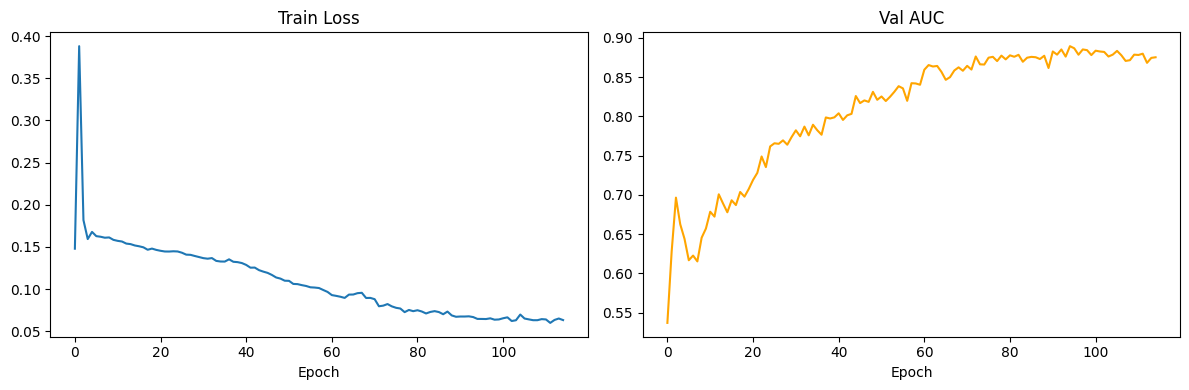


Final embedding diversity — min: 0.2701 | mean: 0.6584 | max: 1.3802


In [28]:
from sklearn.metrics import roc_auc_score

def compute_loss_and_auc(model, edge_projectors, data_gpu, edge_types, device):
    x_dict = inject_edge_features(data_gpu, edge_projectors, device)
    out    = model(x_dict, data_gpu.edge_index_dict)

    total_loss = 0.0
    all_probs, all_labels = [], []

    for etype in edge_types:
        if etype not in data_gpu.edge_types:
            continue
        edge_store = data_gpu[etype]
        if not hasattr(edge_store, 'edge_label'):
            continue

        src_type, _, dst_type = etype
        src    = edge_store.edge_index[0]
        dst    = edge_store.edge_index[1]
        labels = edge_store.edge_label

        if labels.sum() == 0:
            continue

        pred = (out[src_type][src] * out[dst_type][dst]).sum(dim=-1)

        pos_weight = torch.tensor(
            [(labels == 0).sum() / max((labels == 1).sum(), 1)],
            device=device
        )
        loss = F.binary_cross_entropy_with_logits(
            pred, labels, pos_weight=pos_weight
        )
        total_loss += loss

        probs = torch.sigmoid(pred).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

    if len(set(all_labels)) < 2:
        return total_loss, 0.5

    auc = roc_auc_score(all_labels, all_probs)
    return total_loss, auc


EDGE_TYPES = [('user', 'transfers_to', 'user')]

# ── Reinitialize optimizer + scheduler fresh ──────────────────────────────────
optimizer = torch.optim.Adam(
    list(model.parameters()) + list(edge_projectors.parameters()),
    lr=0.005, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max',
    factor=0.5,
    patience=8,          # was 5 — gives more time before reducing LR
    min_lr=1e-5          # floor so LR never dies completely
)

EPOCHS       = 150       # was 60 — model was still improving at cutoff
PATIENCE     = 20        # was 10 — avoid stopping during temporary plateaus
best_val_auc = 0.0
patience_ctr = 0
best_weights = None
history      = {'train_loss': [], 'val_auc': []}

print("Starting GNN training...\n")
for epoch in range(1, EPOCHS + 1):
    model.train()
    edge_projectors.train()
    optimizer.zero_grad()

    train_loss, _ = compute_loss_and_auc(
        model, edge_projectors, train_data_gpu, EDGE_TYPES, device
    )

    if train_loss == 0.0:
        print("WARNING: zero loss — no valid edge types found.")
        break

    train_loss.backward()
    torch.nn.utils.clip_grad_norm_(
        list(model.parameters()) + list(edge_projectors.parameters()),
        max_norm=1.0
    )
    optimizer.step()

    model.eval()
    edge_projectors.eval()
    with torch.no_grad():
        _, val_auc = compute_loss_and_auc(
            model, edge_projectors, val_data_gpu, EDGE_TYPES, device
        )

    scheduler.step(val_auc)
    history['train_loss'].append(train_loss.item())
    history['val_auc'].append(val_auc)

    if epoch % 10 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:03d} | Train Loss: {train_loss.item():.4f} "
              f"| Val AUC: {val_auc:.4f} | LR: {current_lr:.6f}")

    if val_auc > best_val_auc + 1e-4:
        best_val_auc = val_auc
        best_weights = {
            'model'     : copy.deepcopy(model.state_dict()),
            'projectors': copy.deepcopy(edge_projectors.state_dict()),
        }
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}. "
                  f"Best Val AUC: {best_val_auc:.4f}")
            break

model.load_state_dict(best_weights['model'])
edge_projectors.load_state_dict(best_weights['projectors'])
print(f"\nTraining complete. Best Val AUC: {best_val_auc:.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'])
axes[0].set_title("Train Loss"); axes[0].set_xlabel("Epoch")
axes[1].plot(history['val_auc'], color='orange')
axes[1].set_title("Val AUC"); axes[1].set_xlabel("Epoch")
plt.tight_layout(); plt.show()

# ── Post-training diversity check ─────────────────────────────────────────────
with torch.no_grad():
    x_enriched = inject_edge_features(train_data_gpu, edge_projectors, device)
    out_final  = model(x_enriched, train_data_gpu.edge_index_dict)
    emb_final  = out_final['user'].cpu().numpy()

std_final = emb_final.std(axis=0)
print(f"\nFinal embedding diversity — "
      f"min: {std_final.min():.4f} | mean: {std_final.mean():.4f} | max: {std_final.max():.4f}")

In [29]:
model.eval()
edge_projectors.eval()

with torch.no_grad():
    x_dict_train = inject_edge_features(train_data_gpu, edge_projectors, device)
    train_out     = model(x_dict_train, train_data_gpu.edge_index_dict)
    train_embeddings = train_out['user'].cpu().numpy()

    test_data_gpu = test_data.to(device)
    x_dict_test   = inject_edge_features(test_data_gpu, edge_projectors, device)
    test_out      = model(x_dict_test, test_data_gpu.edge_index_dict)
    test_embeddings = test_out['user'].cpu().numpy()

    val_data_gpu2  = val_data.to(device)
    x_dict_val     = inject_edge_features(val_data_gpu2, edge_projectors, device)
    val_out        = model(x_dict_val, val_data_gpu2.edge_index_dict)
    val_embeddings  = val_out['user'].cpu().numpy()

print(f"Train embeddings shape: {train_embeddings.shape}")

# Collapse check
sample      = train_embeddings[:500]
std_per_dim = sample.std(axis=0)
print(f"\nEmbedding diversity — min std: {std_per_dim.min():.4f} | "
      f"mean std: {std_per_dim.mean():.4f} | max std: {std_per_dim.max():.4f}")

if std_per_dim.mean() < 0.01:
    print("WARNING: Embeddings may be collapsed.")
else:
    print("Embeddings look diverse. GNN is working correctly.")

print("\nSample embeddings (first 5 dims):")
for i in range(3):
    print(f"  User {i}: {train_embeddings[i][:5]}")

Train embeddings shape: (843100, 64)

Embedding diversity — min std: 0.2004 | mean std: 0.5098 | max std: 1.2188
Embeddings look diverse. GNN is working correctly.

Sample embeddings (first 5 dims):
  User 0: [ 0.42109373 -0.3430668   0.21518695  0.446749    0.3306747 ]
  User 1: [ 0.89718735 -0.12976389  0.5147138   0.488255    0.47051603]
  User 2: [0.47577628 0.18830791 0.5545599  0.25103638 0.36846334]


In [30]:
from xgboost import XGBClassifier

def prepare_final_features(df_chunk, embeddings, user_map):
    df_enc = pd.get_dummies(df_chunk, columns=['type'], prefix='type')

    emb_features = [
        embeddings[user_map[n]] if n in user_map else np.zeros(64)
        for n in df_enc['nameOrig']
    ]
    emb_df = pd.DataFrame(emb_features,
                           columns=[f'gnn_{i}' for i in range(64)],
                           index=df_enc.index)

    tabular_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
                    'oldbalanceDest', 'newbalanceDest']
    for col in tabular_cols:
        if col not in df_enc.columns:
            df_enc[col] = 0.0

    # Extra handcrafted features
    df_enc['balance_diff_orig'] = df_enc['oldbalanceOrg'] - df_enc['newbalanceOrig']
    df_enc['balance_diff_dest'] = df_enc['newbalanceDest'] - df_enc['oldbalanceDest']
    df_enc['amount_to_balance_ratio'] = df_enc['amount'] / (df_enc['oldbalanceOrg'] + 1)

    extra_cols = ['balance_diff_orig', 'balance_diff_dest', 'amount_to_balance_ratio']
    type_cols  = [c for c in df_enc.columns if c.startswith('type_')]

    X = pd.concat([df_enc[tabular_cols + extra_cols + type_cols], emb_df], axis=1)
    y = df_enc['isFraud']
    return X, y


X_train, y_train = prepare_final_features(train_df, train_embeddings, user_map)
X_val,   y_val   = prepare_final_features(val_df,   val_embeddings,   user_map)
X_test,  y_test  = prepare_final_features(test_df,  test_embeddings,  user_map)

# Compute class weight from actual training distribution
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"Fraud ratio in train → scale_pos_weight = {scale_pos_weight:.2f}")

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    tree_method='hist',
    device='cuda',
    eval_metric='aucpr',       # precision-recall AUC — better for imbalanced data
    early_stopping_rounds=20,
    random_state=42,
)

print("Training XGBoost...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)
print(f"Best iteration: {xgb_model.best_iteration}")

Fraud ratio in train → scale_pos_weight = 168.07
Training XGBoost...
[0]	validation_0-aucpr:0.71956
[50]	validation_0-aucpr:0.87637
[100]	validation_0-aucpr:0.93870
[150]	validation_0-aucpr:0.96022
[200]	validation_0-aucpr:0.97608
[250]	validation_0-aucpr:0.98204
[300]	validation_0-aucpr:0.98458
[350]	validation_0-aucpr:0.98551
[400]	validation_0-aucpr:0.98624
[414]	validation_0-aucpr:0.98603
Best iteration: 394


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [11:54:49] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Chosen threshold: 0.0224
Expected val recall at this threshold: 1.0000


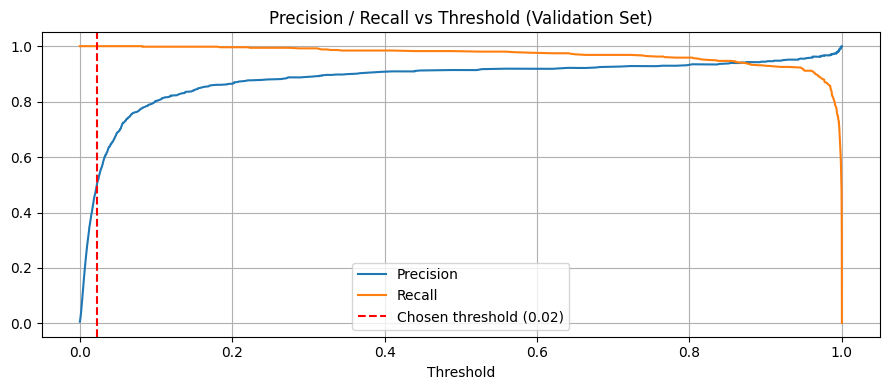

In [31]:
from sklearn.metrics import precision_recall_curve, f1_score

# Get probabilities on validation set
val_probs = xgb_model.predict_proba(X_val)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val, val_probs)

# Find threshold that maximises recall while keeping precision >= 0.5
# (avoids flagging everything as fraud)
best_threshold = 0.5
best_recall    = 0.0

for p, r, t in zip(precision, recall, thresholds):
    if p >= 0.50 and r > best_recall:
        best_recall    = r
        best_threshold = t

print(f"Chosen threshold: {best_threshold:.4f}")
print(f"Expected val recall at this threshold: {best_recall:.4f}")

# Plot precision-recall tradeoff
plt.figure(figsize=(9, 4))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1],    label='Recall')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Chosen threshold ({best_threshold:.2f})')
plt.xlabel('Threshold')
plt.title('Precision / Recall vs Threshold (Validation Set)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

FINAL TEST SET EVALUATION
              precision    recall  f1-score   support

       Legit       1.00      0.99      0.99    152218
       Fraud       0.74      1.00      0.85      4446

    accuracy                           0.99    156664
   macro avg       0.87      0.99      0.92    156664
weighted avg       0.99      0.99      0.99    156664

ROC-AUC: 0.9971


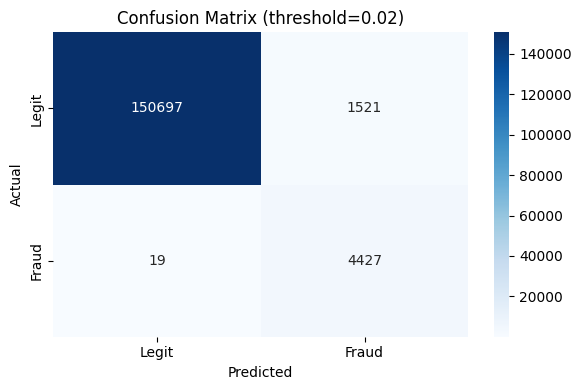

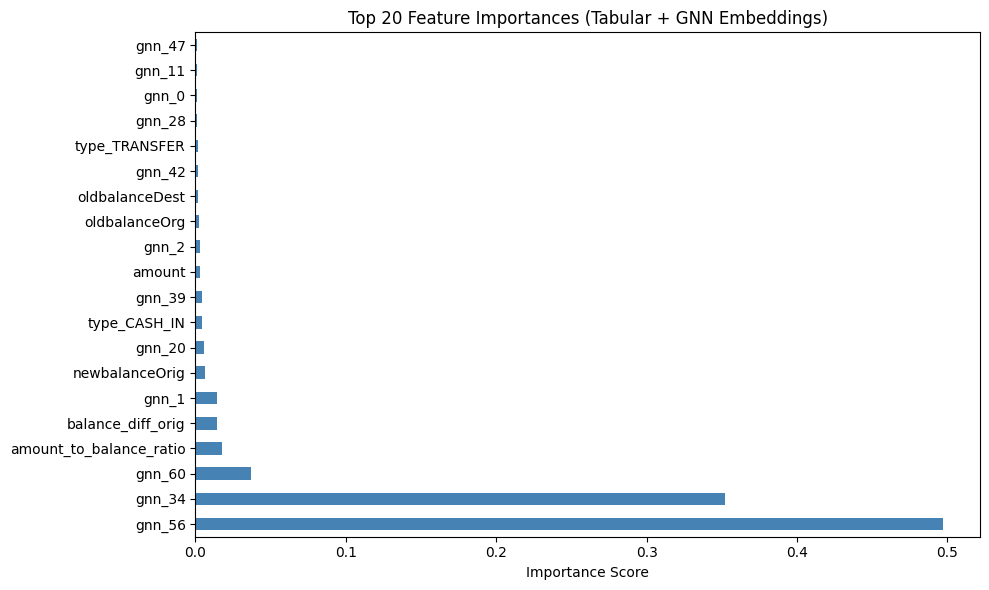

In [32]:
import seaborn as sns

# Apply tuned threshold
test_probs = xgb_model.predict_proba(X_test)[:, 1]
y_pred     = (test_probs >= best_threshold).astype(int)

print("=" * 55)
print("FINAL TEST SET EVALUATION")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

test_auc = roc_auc_score(y_test, test_probs)
print(f"ROC-AUC: {test_auc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'Confusion Matrix (threshold={best_threshold:.2f})')
plt.tight_layout(); plt.show()

# Feature importance
plt.figure(figsize=(10, 6))
feat_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
feat_imp.nlargest(20).plot(kind='barh', color='steelblue')
plt.title("Top 20 Feature Importances (Tabular + GNN Embeddings)")
plt.xlabel("Importance Score")
plt.tight_layout(); plt.show()

In [33]:
import random

def fraud_detective_report(row_index, df_source, X_source, y_source,
                            model, embeddings, user_map, threshold=0.5):
    single_row = X_source.loc[[row_index]]
    prob       = model.predict_proba(single_row)[0][1]
    pred       = 1 if prob >= threshold else 0
    actual     = y_source.loc[row_index]

    # Embedding L2 norm as a proxy structural risk score
    user_name = df_source.loc[row_index, 'nameOrig']
    if user_name in user_map:
        rep_score = float(np.linalg.norm(embeddings[user_map[user_name]]))
    else:
        rep_score = 0.0

    print(f"{'='*55}")
    print(f"  FRAUD DETECTIVE REPORT  —  Transaction #{row_index}")
    print(f"{'='*55}")
    print(f"  Sender:   {user_name}")
    print(f"  Receiver: {df_source.loc[row_index, 'nameDest']}")
    print(f"  Type:     {df_source.loc[row_index, 'type']}")
    print(f"  Amount:   ${df_source.loc[row_index, 'amount']:,.2f}")
    print(f"  Device:   {df_source.loc[row_index, 'device_id']}")
    print(f"{'-'*55}")
    print(f"  GNN structural risk score : {rep_score:.4f}")
    print(f"  Model fraud probability   : {prob*100:.2f}%")
    print(f"  Decision threshold        : {threshold:.2f}")
    print(f"{'-'*55}")

    icon_pred   = "🚨 FRAUD" if pred   == 1 else "✅ LEGIT"
    icon_actual = "🚨 FRAUD" if actual == 1 else "✅ LEGIT"
    print(f"  Prediction : {icon_pred}")
    print(f"  Ground truth: {icon_actual}")
    print()

    if pred == actual:
        print("  ✨ CORRECT DETECTION")
    else:
        label = "FALSE POSITIVE" if pred == 1 else "MISSED FRAUD"
        print(f"  ⚠️  {label}")
    print(f"{'='*55}")


# --- Run on 3 random test transactions ---
# Use df index aligned with X_test
test_indices = list(X_test.index)
for _ in range(3):
    idx = random.choice(test_indices)
    fraud_detective_report(idx, test_df, X_test, y_test,
                            xgb_model, test_embeddings, user_map,
                            threshold=best_threshold)
    print()

  FRAUD DETECTIVE REPORT  —  Transaction #29096
  Sender:   C483292701
  Receiver: C1613492129
  Type:     CASH_OUT
  Amount:   $169,398.45
  Device:   DEVICE_927327
-------------------------------------------------------
  GNN structural risk score : 4.3955
  Model fraud probability   : 0.04%
  Decision threshold        : 0.02
-------------------------------------------------------
  Prediction : ✅ LEGIT
  Ground truth: ✅ LEGIT

  ✨ CORRECT DETECTION

  FRAUD DETECTIVE REPORT  —  Transaction #38624
  Sender:   C1270085499
  Receiver: C288110133
  Type:     CASH_OUT
  Amount:   $172,647.37
  Device:   DEVICE_194895
-------------------------------------------------------
  GNN structural risk score : 5.6348
  Model fraud probability   : 0.02%
  Decision threshold        : 0.02
-------------------------------------------------------
  Prediction : ✅ LEGIT
  Ground truth: ✅ LEGIT

  ✨ CORRECT DETECTION

  FRAUD DETECTIVE REPORT  —  Transaction #110443
  Sender:   C71438154
  Receiver: C23

In [36]:
import os
import json
import pickle
from datetime import datetime

SAVE_DIR = '/content/drive/MyDrive/jatayu_fraud_model'
os.makedirs(SAVE_DIR, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
print(f"Saving to: {SAVE_DIR}")
print(f"Timestamp: {timestamp}\n")

# ── 1. GNN model weights ──────────────────────────────────────────────────────
# Replace the GNN save block in Cell 14 with this
gnn_path = f"{SAVE_DIR}/gnn_model_{timestamp}.pt"
torch.save({
    'model_state_dict'     : model.state_dict(),
    'projectors_state_dict': edge_projectors.state_dict(),
    'hidden_channels'      : int(HIDDEN),
    'out_channels'         : int(OUT),
    'dropout'              : 0.3,
    'best_val_auc'         : float(best_val_auc),
    'timestamp'            : timestamp,
}, gnn_path)

# Save metadata separately so torch.load never touches numpy objects
metadata_path = f"{SAVE_DIR}/gnn_metadata_{timestamp}.pkl"
with open(metadata_path, 'wb') as f:
    pickle.dump({'model_metadata': train_data.metadata()}, f)

print(f"[1/6] GNN model saved        → {gnn_path}")
print(f"      GNN metadata saved     → {metadata_path}")
# ── 2. XGBoost model ──────────────────────────────────────────────────────────
xgb_path = f"{SAVE_DIR}/xgb_model_{timestamp}.pkl"
with open(xgb_path, 'wb') as f:
    pickle.dump(xgb_model, f)
print(f"[2/6] XGBoost model saved    → {xgb_path}")

# ── 3. Embeddings (train + val + test) ────────────────────────────────────────
emb_path = f"{SAVE_DIR}/embeddings_{timestamp}.npz"
np.savez_compressed(
    emb_path,
    train=train_embeddings,   # shape (N_users, 64)
    val=val_embeddings,
    test=test_embeddings,
)
print(f"[3/6] Embeddings saved       → {emb_path}")

# ── 4. Node & entity mappings ─────────────────────────────────────────────────
# These are needed at inference time to map new account names to node indices
mappings_path = f"{SAVE_DIR}/mappings_{timestamp}.pkl"
with open(mappings_path, 'wb') as f:
    pickle.dump({
        'user_map'    : user_map,
        'merchant_map': merchant_map,
        'ip_map'      : ip_map,
        'device_map'  : device_map,
    }, f)
print(f"[4/6] Entity mappings saved  → {mappings_path}")

# ── 5. Feature scalers ────────────────────────────────────────────────────────
# Needed to transform raw features for new users at inference time
scalers_path = f"{SAVE_DIR}/scalers_{timestamp}.pkl"
with open(scalers_path, 'wb') as f:
    pickle.dump({
        'user_scaler'    : user_scaler,
        'ip_scaler'      : ip_scaler,
        'device_scaler'  : device_scaler,
        'merchant_scaler': merchant_scaler,
    }, f)
print(f"[5/6] Feature scalers saved  → {scalers_path}")

# ── 6. Run config — everything needed to reproduce or reload ──────────────────
config = {
    'timestamp'       : timestamp,
    'best_val_auc'    : float(best_val_auc),
    'best_threshold'  : float(best_threshold),
    'hidden_channels' : HIDDEN,
    'out_channels'    : OUT,
    'dropout'         : 0.3,
    'gnn_epochs'      : len(history['train_loss']),
    'scale_pos_weight': float(scale_pos_weight),
    'global_max_step' : int(global_max_step),
    'train_size'      : len(train_df),
    'val_size'        : len(val_df),
    'test_size'       : len(test_df),
    'n_users'         : len(user_map),
    'n_merchants'     : len(merchant_map),
    'n_ips'           : len(ip_map),
    'n_devices'       : len(device_map),
    'embedding_dim'   : OUT,
    'files': {
        'gnn_model' : os.path.basename(gnn_path),
        'xgb_model' : os.path.basename(xgb_path),
        'embeddings': os.path.basename(emb_path),
        'mappings'  : os.path.basename(mappings_path),
        'scalers'   : os.path.basename(scalers_path),
    }
}
config_path = f"{SAVE_DIR}/config_{timestamp}.json"
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"[6/6] Config saved           → {config_path}")

print(f"\nAll files saved to {SAVE_DIR}")
print(f"\nTo reload everything later, use config_{timestamp}.json as your index.")

Saving to: /content/drive/MyDrive/jatayu_fraud_model
Timestamp: 20260304_120501

[1/6] GNN model saved        → /content/drive/MyDrive/jatayu_fraud_model/gnn_model_20260304_120501.pt
      GNN metadata saved     → /content/drive/MyDrive/jatayu_fraud_model/gnn_metadata_20260304_120501.pkl
[2/6] XGBoost model saved    → /content/drive/MyDrive/jatayu_fraud_model/xgb_model_20260304_120501.pkl
[3/6] Embeddings saved       → /content/drive/MyDrive/jatayu_fraud_model/embeddings_20260304_120501.npz
[4/6] Entity mappings saved  → /content/drive/MyDrive/jatayu_fraud_model/mappings_20260304_120501.pkl
[5/6] Feature scalers saved  → /content/drive/MyDrive/jatayu_fraud_model/scalers_20260304_120501.pkl
[6/6] Config saved           → /content/drive/MyDrive/jatayu_fraud_model/config_20260304_120501.json

All files saved to /content/drive/MyDrive/jatayu_fraud_model

To reload everything later, use config_20260304_120501.json as your index.


In [37]:
# ── RELOAD & INFERENCE — paste this into any future notebook ─────────────────

import torch, pickle, json, numpy as np
from torch_geometric.nn import SAGEConv, to_hetero
import torch.nn.functional as F

SAVE_DIR  = '/content/drive/MyDrive/jatayu_fraud_model'

# ── Point this to whichever timestamp you want to load ───────────────────────
CONFIG_FILE = f"{SAVE_DIR}/config_{timestamp}.json"   # or hardcode the timestamp

with open(CONFIG_FILE) as f:
    cfg = json.load(f)

print(f"Loading model from {cfg['timestamp']}")
print(f"  Val AUC at save time : {cfg['best_val_auc']:.4f}")
print(f"  Decision threshold   : {cfg['best_threshold']:.4f}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Load mappings & scalers ───────────────────────────────────────────────────
with open(f"{SAVE_DIR}/{cfg['files']['mappings']}", 'rb') as f:
    maps = pickle.load(f)
user_map     = maps['user_map']
merchant_map = maps['merchant_map']
ip_map       = maps['ip_map']
device_map   = maps['device_map']

with open(f"{SAVE_DIR}/{cfg['files']['scalers']}", 'rb') as f:
    scalers = pickle.load(f)

print(f"\nMappings loaded — {len(user_map):,} users, "
      f"{len(merchant_map):,} merchants")

# ── Rebuild GNN architecture & load weights ───────────────────────────────────
class HeteroGNN(torch.nn.Module):
    def __init__(self, hidden_channels, out_channels, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        self.conv1 = SAGEConv((-1, -1), hidden_channels)
        self.conv2 = SAGEConv((-1, -1), hidden_channels)
        self.conv3 = SAGEConv((-1, -1), out_channels)
        self.bn1   = torch.nn.BatchNorm1d(hidden_channels)
        self.bn2   = torch.nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv3(x, edge_index)

# Replace the ckpt load + model build block in Cell 15 with this
ckpt = torch.load(
    f"{SAVE_DIR}/{cfg['files']['gnn_model']}",
    map_location=device,
    weights_only=True    # now safe — no numpy objects in checkpoint
)

# Load metadata separately
meta_filename = cfg['files']['gnn_model'].replace('gnn_model_', 'gnn_metadata_').replace('.pt', '.pkl')
with open(f"{SAVE_DIR}/{meta_filename}", 'rb') as f:
    meta = pickle.load(f)

model = HeteroGNN(cfg['hidden_channels'], cfg['out_channels'], cfg['dropout'])
model = to_hetero(model, meta['model_metadata'], aggr='mean')
model = model.to(device)

edge_projectors = torch.nn.ModuleDict({
    'transfers_to' : torch.nn.Linear(3, cfg['hidden_channels']),
    'pays_to'      : torch.nn.Linear(2, cfg['hidden_channels']),
    'connects_from': torch.nn.Linear(1, cfg['hidden_channels']),
    'uses_device'  : torch.nn.Linear(1, cfg['hidden_channels']),
}).to(device)

model.load_state_dict(ckpt['model_state_dict'])
edge_projectors.load_state_dict(ckpt['projectors_state_dict'])
model.eval()
edge_projectors.eval()
print("GNN loaded and ready.")

# ── Load XGBoost ──────────────────────────────────────────────────────────────
with open(f"{SAVE_DIR}/{cfg['files']['xgb_model']}", 'rb') as f:
    xgb_model = pickle.load(f)
print("XGBoost loaded and ready.")

# ── Load saved embeddings (for analysis / visualisation) ─────────────────────
emb_data = np.load(f"{SAVE_DIR}/{cfg['files']['embeddings']}")
train_embeddings = emb_data['train']
val_embeddings   = emb_data['val']
test_embeddings  = emb_data['test']
print(f"\nEmbeddings loaded:")
print(f"  train : {train_embeddings.shape}")
print(f"  val   : {val_embeddings.shape}")
print(f"  test  : {test_embeddings.shape}")

best_threshold = cfg['best_threshold']
print(f"\nDecision threshold: {best_threshold:.4f}")
print("\nReady for inference.")

Loading model from 20260304_120501
  Val AUC at save time : 0.8893
  Decision threshold   : 0.0224

Mappings loaded — 843,100 users, 34,394 merchants
GNN loaded and ready.
XGBoost loaded and ready.


/usr/local/lib/python3.12/dist-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  return transformer.transform()
/usr/local/lib/python3.12/dist-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout_1' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  return transformer.transform()



Embeddings loaded:
  train : (843100, 64)
  val   : (843100, 64)
  test  : (843100, 64)

Decision threshold: 0.0224

Ready for inference.
